In [1]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)
X, y = mnist["data"], mnist["target"]

In [2]:
X.shape # (columns, rows)

(70000, 784)

In [3]:
y

array(['5', '0', '4', ..., '4', '5', '6'], shape=(70000,), dtype=object)

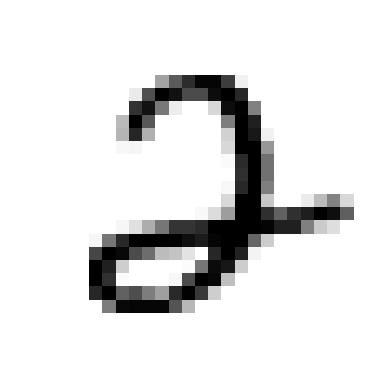

In [4]:
import matplotlib.pyplot as plt

def plot_img(image_data):
    img = image_data.reshape(28,28)
    plt.imshow(img, cmap="binary")
    plt.axis("off")

some_digit = X[16]
plot_img(some_digit)
plt.show()

In [5]:
y[1]

'0'

In [6]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

In [7]:
# Training a Binary Classifier
y_train_2 = (y_train == '2')
y_test_2 = (y_test == '2')

In [8]:
# Train using Stochastic Gradient Descent (SGD) Classifier
from sklearn.linear_model import SGDClassifier
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_2)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [9]:
sgd_clf.predict([some_digit])

array([ True])

In [10]:
# Cross Validation to measure accuracy of the model
from sklearn.model_selection import cross_val_score

cross_val_score(sgd_clf, X_train, y_train_2, cv = 5, scoring="accuracy")

array([0.96683333, 0.95933333, 0.96775   , 0.97375   , 0.97333333])

In [11]:
from sklearn.dummy import DummyClassifier
dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_2)
print(any(dummy_clf.predict(X_train)))

False


In [12]:
cross_val_score(dummy_clf, X_train, y_train_2, cv = 3, scoring="accuracy")

array([0.9007, 0.9007, 0.9007])

In [13]:
# Stratified K-fold Cross Validation

from sklearn.base import clone

from sklearn.model_selection import StratifiedKFold
skfolds = StratifiedKFold(n_splits=3, random_state=42, shuffle=True)

for train_idx, test_idx in skfolds.split(X_train, y_train_2):
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train[train_idx]
    y_train_folds = y_train_2[train_idx]
    X_test_fold = X_train[test_idx]
    y_test_fold = y_train_2[test_idx]

    clone_clf.fit(X_train_folds, y_train_folds)
    y_predict = clone_clf.predict(X_test_fold)
    n_correct = sum(y_predict == y_test_fold)

    print(n_correct / len(y_predict))


0.96895
0.9717
0.9676


In [14]:
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_2, cv=3)

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_train_2, y_train_pred)
cm


array([[51538,  2504],
       [  908,  5050]])

In [15]:
y_predict_perf = y_train_2
confusion_matrix(y_train_2, y_predict_perf)

array([[54042,     0],
       [    0,  5958]])

In [16]:
from sklearn.metrics import precision_score, recall_score

precision_score(y_train_2, y_train_pred)
recall_score(y_train_2, y_train_pred)

0.8475998657267539

In [17]:
from sklearn.metrics import f1_score

f1_score(y_train_2, y_train_pred)

0.7474837181764358

In [18]:
# decision function
y_scores = sgd_clf.decision_function([some_digit])
y_scores

array([1628.05044666])

In [19]:
threshold = 1800
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([False])

In [20]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_2, cv=3, method="decision_function") # confidence scores for all instances in the training set

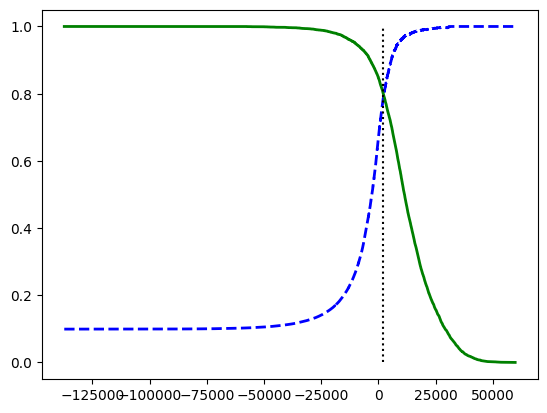

In [21]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_2, y_scores)

plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.vlines(threshold, 0, 1.0, "k", "dotted", label="Threshold")

In [22]:
indx_for_90_precision = (precisions >= 0.90).argmax()
threshold_90_precision = thresholds[indx_for_90_precision]
threshold_90_precision

np.float64(5585.140261597363)

In [23]:
y_train_pred_90 = (y_scores >= threshold_90_precision)
precision_score(y_train_2, y_train_pred_90)
recall_score(y_train_2, y_train_pred_90)

0.7059415911379657

In [25]:
# ROC Curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_train_2, y_scores)

In [26]:
# point for 90% precision
idx_for_threshold_90 = (thresholds >= threshold_90_precision).argmax()
tpr_90, fpr_90 = tpr[idx_for_threshold_90], fpr[idx_for_threshold_90]
tpr_90, fpr_90

(np.float64(0.0), np.float64(0.0))

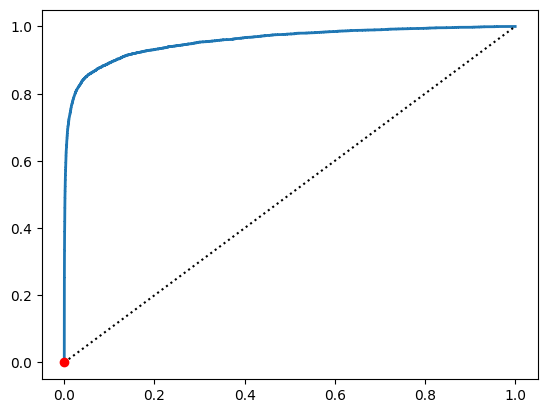

In [27]:
plt.plot(fpr, tpr, linewidth=2, label="ROC Curve")
plt.plot([0,1], [0,1], "k:", label="Random Classifier")
plt.plot(fpr_90, tpr_90, "ro", label="Threshold 90% Precision")

In [28]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_train_2, y_scores)

0.9568395257681235